<a href="https://colab.research.google.com/github/Caelik/genre_classification/blob/main/GenerateDataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd

df = pd.read_csv("customer_purchases.csv")

# calculate total revenue by row
df['revenue'] = df['quantity'] * df["price_per_unit"]

df.dtypes

# Group by product and sum the revenue
revenue_by_product = df.groupby('product')["revenue"].sum().sort_values(ascending=False)

# Get top 5
top_5_products = revenue_by_product.head(5)

# Display
top_5_products

# # Save Top 5 Products
# df.to_csv('top_5_products.csv')



,revenue
product,
Gizmo C,6320.0
Widget A,3525.0
Doodad,3078.0
Widget B,2640.0
Thingamajig,1344.0


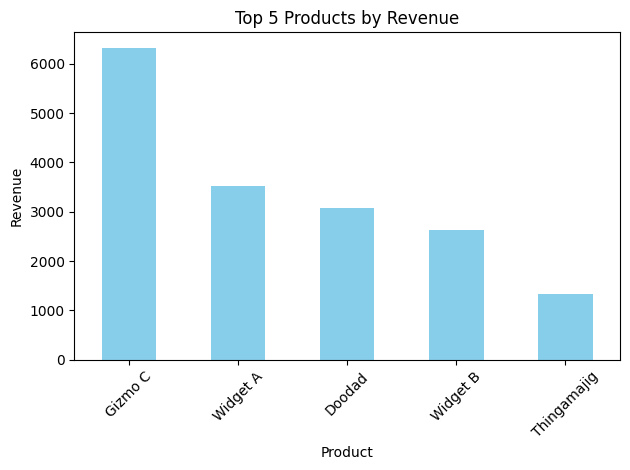

In [16]:
import matplotlib.pyplot as plt

top_5_products.plot(kind="bar", title="Top 5 Products by Revenue", ylabel="Revenue", xlabel="Product", color="skyblue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df = pd.read_csv("customer_purchases.csv")
df["revenue"] = df['quantity'] * df['price_per_unit']

df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.to_period("M")

monthly_revenue = df.groupby("order_month")['revenue'].sum().sort_index()
monthly_revenue

# Save Monthyl Revenue
df.to_csv('MonthlyRevenue - AO 29 Jul 25')

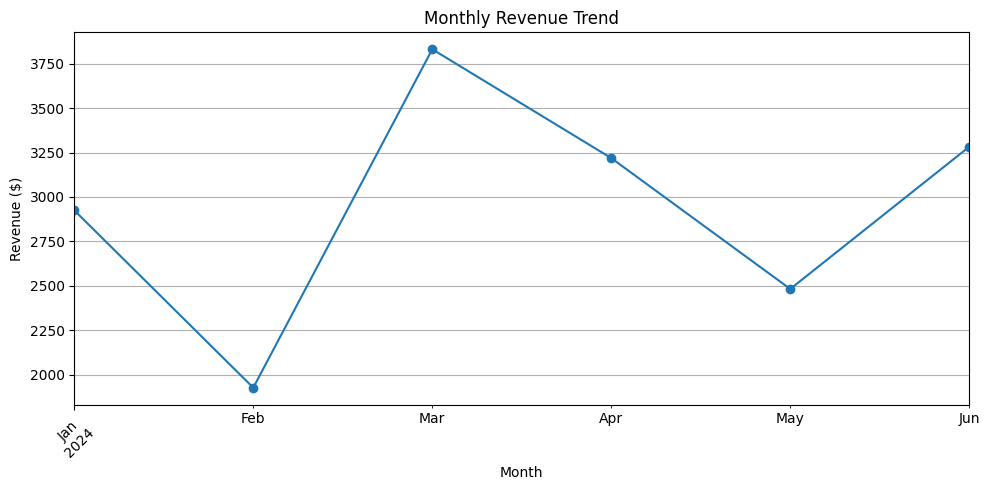

In [18]:
monthly_revenue.plot(kind='line', marker='o', title='Monthly Revenue Trend', ylabel='Revenue ($)', xlabel='Month', figsize=(10,5))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
df = pd.read_csv('customer_purchases.csv')
df['revenue'] = df['quantity'] * df["price_per_unit"]
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')

df.to_csv('customer_purchases_cleaned.csv')


In [34]:
df = pd.read_csv('customer_purchases_cleaned.csv')

aov_by_month = df.groupby('order_month').agg({
    'revenue': 'sum',
    'order_id': 'nunique'
})

aov_by_month['AOV'] = aov_by_month['revenue'] / aov_by_month['order_id']
aov_by_month = aov_by_month.sort_index()
aov_by_month[['AOV']]


,AOV
order_month,
2024-01,59.693878
2024-02,53.500000
2024-03,67.228070
2024-04,56.473684
2024-05,49.640000
2024-06,64.372549


In [35]:
aov_df = aov_by_month.reset_index()
aov_df.columns = ['Month', 'Total Revenue', 'Order Count', 'AOV']
aov_df

,Month,Total Revenue,Order Count,AOV
0,2024-01,2925.0,49,59.693878
1,2024-02,1926.0,36,53.500000
2,2024-03,3832.0,57,67.228070
3,2024-04,3219.0,57,56.473684
4,2024-05,2482.0,50,49.640000
5,2024-06,3283.0,51,64.372549


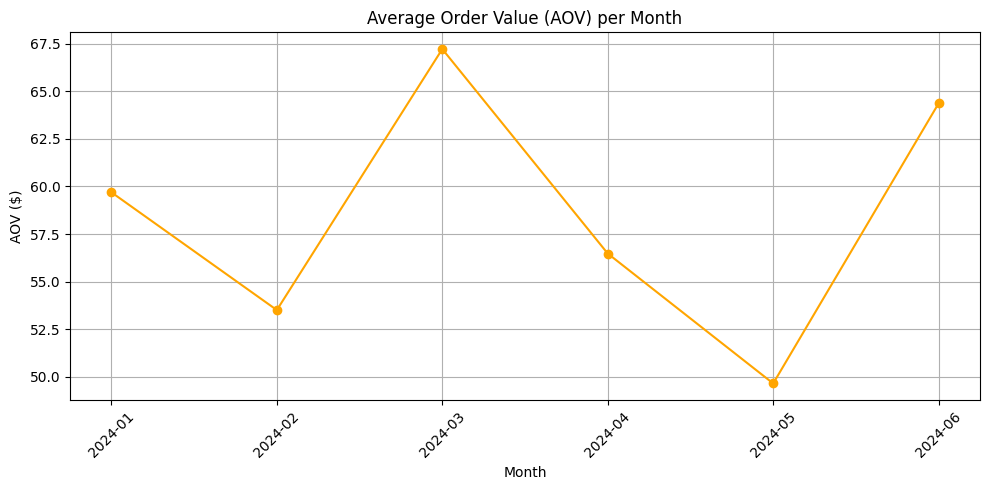

In [36]:
plt.figure(figsize=(10,5))
plt.plot(aov_by_month.index.astype(str), aov_by_month['AOV'], marker='o', color='orange')
plt.title('Average Order Value (AOV) per Month')
plt.xlabel('Month')
plt.ylabel('AOV ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
orders_per_customer = df.groupby('customer_id')['order_id'].nunique()

repeat_customers = orders_per_customer[orders_per_customer > 1].count()
total_customers = orders_per_customer.count()
print(f'Repeat Customers Total: {repeat_customers}')
print(f'Total Customers: {total_customers}')

repeat_rate = repeat_customers / total_customers
print(f'Repeat Customer Rate: {repeat_rate:.2%}')

Repeat Customers Total: 48
Total Customers: 50
Repeat Customer Rate: 96.00%


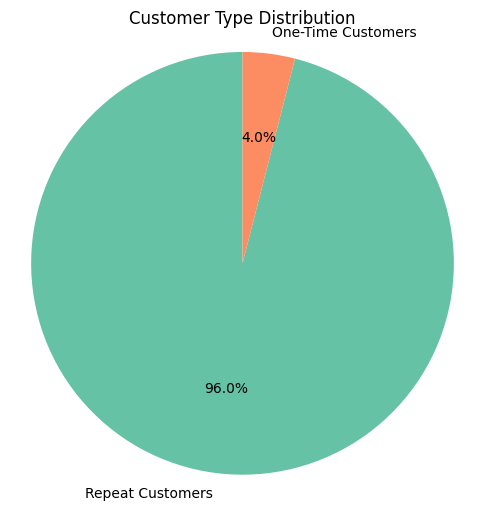

In [40]:
counts = [repeat_customers, total_customers - repeat_customers]
labels = ['Repeat Customers', 'One-Time Customers']

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,colors=['#66c2a5', '#fc8d62'])
plt.title('Customer Type Distribution')
plt.axis('equal')
plt.show()


# Summary of Findings - Customer Purchase Dataset

### Dataset Overview
- *Time Period:* Jan 1, 2024 = Jun 30, 2024
- *Total Orders:* 300
- *Unique Customers:* 50
- *Total Revenue*
- *Average Order Value (AOV):*

---

### Top 5 Products by Revenue:
1. Gizmo C - \$6,320
2. Widget A - \$3,525
3. Doodad - \$3,078
4. Widget B - \$2,640
5. Thingamajig - \$1,344


---

### Monthly Revenue Trend
- Revenue peaked in *March 2024*
- Lowest Revenue in *May 2024*
- Steady decline from Q1 to Q2 but a sharp rebound in June 2024

---

### Average Order Value (AOV) Trend:
- AOV increased from *\$* in MONTH to *\$* in MONTH
- Suggests increasing order sizes or upselling success

---

### Repeat Customer Rate
- *96%* of customers placed more than one order
- Indicates solid customer retention
- May benefit from loyalty programs or targeted offers

---

### Actionable Insights